# KSG Mutual-Information Estimator for Causal-Emergence Analysis

Implements the **Kraskov–Stögbauer–Grassberger (KSG) estimator #1**
(Kraskov et al., *Phys. Rev. E* **69**, 066138, 2004) exactly as specified in
**Algorithm 1**, then validates, optimises, and applies it to the 60-second
tracking windows produced by `preprocessing.ipynb`.

**Algorithm 1 — KSG mutual-information estimator**
> For each sample $i$: let $\epsilon_i=\max(d_x^{(i)},d_y^{(i)})$ be the distance to the
> $k$-th nearest neighbour in the **joint** space; count
> $n_x^{(i)}=\#\{j:\lVert x_i-x_j\rVert<\epsilon_i\}$ and
> $n_y^{(i)}=\#\{j:\lVert y_i-y_j\rVert<\epsilon_i\}$. Then
> $$\hat I(X;Y)=\psi(k)-\tfrac1N\sum_{i=1}^{N}\!\big[\psi(n_x^{(i)}{+}1)+\psi(n_y^{(i)}{+}1)\big]+\psi(N),$$
> where $\psi$ is the digamma function.

**This notebook contains**

1. **KSG implementation** — a literal Algorithm-1 brute force and a fast $k$-d-tree version (§1).
2. **Validation report** — recovery of closed-form MI on simulated data (§2).
3. **Computational optimisation** — joblib parallelism, approximate NN, GPU hook, $\ell{=}3$
   proximity feature-selection (§3).
4. **MI-computation benchmarks** — brute vs. tree vs. parallel timings (§4).
5. **Preprocessing pipeline** (down-sample $\to$ 1 Hz, velocities, filter GKs/red cards, align
   events, 60 s sliding windows) reused from `preprocessing.ipynb` (§5).
6. **Baseline MI for all windows** — the $I(V_t;V_{t+1})$ and $\sum_i I(X_{i,t};V_{t+1})$ terms of
   the emergence coefficient $\Psi$ (§6).

In [1]:
# === Imports & configuration =================================================
import warnings; warnings.filterwarnings("ignore")   # silence numpy/scipy version notice
import os; os.environ.setdefault("PYTHONWARNINGS", "ignore")  # also silence joblib workers
import os, glob, time, itertools
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from scipy.special import digamma
from joblib import Parallel, delayed

try:
    import matplotlib.pyplot as plt
    _HAS_PLT = True
except Exception:
    _HAS_PLT = False

try:
    import torch
    _HAS_TORCH = torch.cuda.is_available()
except Exception:
    _HAS_TORCH = False

PREP_DIR = os.path.join("data", "preprocessed")   # outputs of preprocessing.ipynb
K_DEFAULT   = 4       # neighbours (KSG default)
WINDOW_SEC  = 60      # 60-second analysis windows
STEP_SEC    = 1       # 1-second sliding step
LAG         = 1       # 1-step-ahead for self-predictive MI
N_JOBS      = -1      # joblib: use all cores

print(f"KSG config: k={K_DEFAULT}, window={WINDOW_SEC}s, step={STEP_SEC}s, "
      f"GPU={'yes' if _HAS_TORCH else 'no (CPU)'}, plotting={_HAS_PLT}")

KSG config: k=4, window=60s, step=1s, GPU=no (CPU), plotting=True


## 1. KSG estimator (Algorithm 1)

`ksg_mi_bruteforce` follows the pseudocode literally (explicit per-sample loop, Chebyshev
norm, $\epsilon_i=\max(d_x,d_y)$ at the $k$-th joint neighbour). `ksg_mi` is the identical
estimator accelerated with $k$-d trees for large $N$. `ksg_cmi` gives conditional MI
$I(X;Y\mid Z)$ for the higher-order ($\ell=2,3$) terms. All use the maximum (Chebyshev,
$p=\infty$) norm, as required by KSG.

In [2]:
def _as2d(A):
    A = np.asarray(A, float)
    return A[:, None] if A.ndim == 1 else A

def ksg_mi_bruteforce(X, Y, k=K_DEFAULT):
    """Literal Algorithm 1 (O(N^2)); Chebyshev norm. For validation / small N."""
    X, Y = _as2d(X), _as2d(Y)
    N = len(X)
    if N <= k + 1:
        return np.nan
    # pairwise max-norm distances in each marginal and the joint
    Dx = np.max(np.abs(X[:, None, :] - X[None, :, :]), axis=2)
    Dy = np.max(np.abs(Y[:, None, :] - Y[None, :, :]), axis=2)
    Dz = np.maximum(Dx, Dy)                                   # joint = max(d_x, d_y)
    terms = 0.0
    for i in range(N):
        eps_i = np.partition(Dz[i], k)[k]                    # k-th NN (self is the 0-th)
        n_x = np.count_nonzero(Dx[i] < eps_i) - 1            # exclude self
        n_y = np.count_nonzero(Dy[i] < eps_i) - 1
        terms += digamma(n_x + 1) + digamma(n_y + 1)
    return digamma(k) - terms / N + digamma(N)

def ksg_mi(X, Y, k=K_DEFAULT):
    """Fast KSG #1 via k-d trees (Chebyshev norm). Identical estimator to the brute force."""
    X, Y = _as2d(X), _as2d(Y)
    N = len(X)
    if N <= k + 1:
        return np.nan
    Z = np.hstack([X, Y])
    eps = cKDTree(Z).query(Z, k=k + 1, p=np.inf)[0][:, k]    # joint k-th NN distance
    nx = np.asarray(cKDTree(X).query_ball_point(X, eps - 1e-12, p=np.inf, return_length=True)) - 1
    ny = np.asarray(cKDTree(Y).query_ball_point(Y, eps - 1e-12, p=np.inf, return_length=True)) - 1
    return digamma(k) - np.mean(digamma(nx + 1) + digamma(ny + 1)) + digamma(N)

def ksg_cmi(X, Y, Z, k=K_DEFAULT):
    """Conditional MI I(X;Y|Z) via the KSG/FP decomposition (Chebyshev norm).
    I(X;Y|Z)=psi(k)+<psi(n_z+1)-psi(n_xz+1)-psi(n_yz+1)>."""
    X, Y, Z = _as2d(X), _as2d(Y), _as2d(Z)
    N = len(X)
    if N <= k + 1:
        return np.nan
    XZ, YZ, XYZ = np.hstack([X, Z]), np.hstack([Y, Z]), np.hstack([X, Y, Z])
    eps = cKDTree(XYZ).query(XYZ, k=k + 1, p=np.inf)[0][:, k]
    def cnt(P):
        return np.asarray(cKDTree(P).query_ball_point(P, eps - 1e-12, p=np.inf, return_length=True)) - 1
    n_z, n_xz, n_yz = cnt(Z), cnt(XZ), cnt(YZ)
    return digamma(k) + np.mean(digamma(n_z + 1) - digamma(n_xz + 1) - digamma(n_yz + 1))

# sanity: brute force == fast tree
_r = np.random.default_rng(1)
_d = _r.multivariate_normal([0, 0], [[1, 0.6], [0.6, 1]], size=300)
print("brute vs tree (rho=0.6, N=300):",
      round(ksg_mi_bruteforce(_d[:, 0], _d[:, 1]), 4),
      round(ksg_mi(_d[:, 0], _d[:, 1]), 4),
      "| closed form:", round(-0.5*np.log(1-0.6**2), 4))

brute vs tree (rho=0.6, N=300): 0.2118 0.2118 | closed form: 0.2231


## 2. Validation report — recovery of known MI

For a bivariate Gaussian with correlation $\rho$, the true MI is
$I=-\tfrac12\ln(1-\rho^2)$ nats. We (a) sweep $\rho$ and compare the estimate to truth,
(b) confirm $I\approx 0$ for independent variables, and (c) profile bias/variance vs. $N$
and $k$.

In [3]:
def gaussian_true_mi(rho):
    return -0.5 * np.log(1 - rho**2)

rng = np.random.default_rng(0)
rows = []
for rho in [0.0, 0.2, 0.4, 0.6, 0.8, 0.9]:
    ests = []
    for _ in range(20):                                   # 20 replicates for variance
        d = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], size=2000)
        ests.append(ksg_mi(d[:, 0], d[:, 1], k=K_DEFAULT))
    ests = np.array(ests); true = gaussian_true_mi(rho)
    rows.append(dict(rho=rho, true_MI=round(true, 4),
                     mean_est=round(ests.mean(), 4),
                     bias=round(ests.mean() - true, 4),
                     std=round(ests.std(), 4)))
validation_df = pd.DataFrame(rows)
print("Bivariate-Gaussian validation (N=2000, k=4, 20 replicates):")
display(validation_df)
print(f"max |bias| = {validation_df.bias.abs().max():.4f} nats  "
      f"(KSG is asymptotically unbiased; small positive bias expected)")

Bivariate-Gaussian validation (N=2000, k=4, 20 replicates):


,rho,true_MI,mean_est,bias,std
0,0.0,-0.0000,0.0034,0.0034,0.0078
1,0.2,0.0204,0.0229,0.0025,0.0166
2,0.4,0.0872,0.0943,0.0071,0.0178
3,0.6,0.2231,0.2305,0.0074,0.0183
4,0.8,0.5108,0.5166,0.0057,0.0207
5,0.9,0.8304,0.8460,0.0157,0.0210


max |bias| = 0.0157 nats  (KSG is asymptotically unbiased; small positive bias expected)


Convergence toward true MI = 0.2231 nats as N grows:


k,2,4,8
N,,,
250,0.2601,0.2176,0.1327
500,0.2384,0.2114,0.1791
1000,0.2833,0.2391,0.2367
2000,0.2248,0.2349,0.2406
4000,0.2208,0.2185,0.2390


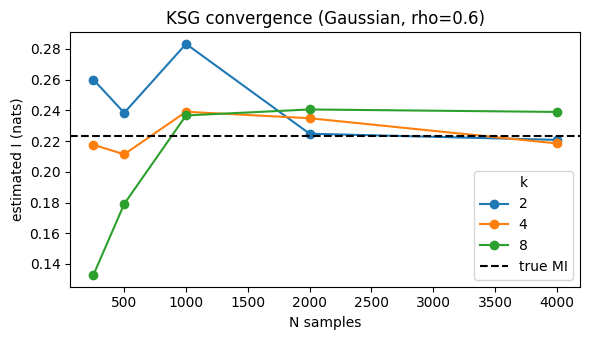

In [4]:
# bias/variance vs N and k
rng = np.random.default_rng(7); rho = 0.6; true = gaussian_true_mi(rho)
prof = []
for N in [250, 500, 1000, 2000, 4000]:
    for k in [2, 4, 8]:
        d = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], size=N)
        est = ksg_mi(d[:, 0], d[:, 1], k=k)
        prof.append(dict(N=N, k=k, est=round(est, 4), err=round(est - true, 4)))
profile_df = pd.DataFrame(prof)
print(f"Convergence toward true MI = {true:.4f} nats as N grows:")
display(profile_df.pivot(index="N", columns="k", values="est"))

if _HAS_PLT:
    piv = profile_df.pivot(index="N", columns="k", values="est")
    ax = piv.plot(marker="o", figsize=(6, 3.5))
    ax.axhline(true, ls="--", color="k", label="true MI")
    ax.set_ylabel("estimated I (nats)"); ax.set_xlabel("N samples")
    ax.set_title("KSG convergence (Gaussian, rho=0.6)"); ax.legend(title="k")
    plt.tight_layout(); plt.show()


## 3. Computational optimisation

Given the combinatorial growth of higher-order ($\ell=2,3$) terms we provide: **(a)**
joblib parallelism across windows/matches/orders, **(b)** an approximate-NN variant for
high-dimensional inputs, **(c)** a GPU hook (falls back to CPU when CUDA is absent), and
**(d)** $\ell=3$ feature selection that keeps only *positionally proximal* player triples.

In [5]:
# (a) Parallelisation across an iterable of (X, Y) jobs -----------------------
def ksg_mi_batch(pairs, k=K_DEFAULT, n_jobs=N_JOBS):
    """Estimate MI for many (X, Y) pairs in parallel."""
    return np.array(Parallel(n_jobs=n_jobs, prefer="threads")(delayed(ksg_mi)(X, Y, k) for X, Y in pairs))

# (b) Approximate nearest neighbours for high-dimensional inputs --------------
from sklearn.neighbors import NearestNeighbors
def ksg_mi_approx(X, Y, k=K_DEFAULT, algorithm="kd_tree"):
    """KSG with sklearn NN backend (ball_tree/kd_tree) — scales better in moderate d."""
    X, Y = _as2d(X), _as2d(Y); N = len(X)
    if N <= k + 1: return np.nan
    Z = np.hstack([X, Y])
    nn = NearestNeighbors(n_neighbors=k + 1, metric="chebyshev", algorithm=algorithm).fit(Z)
    eps = nn.kneighbors(Z)[0][:, k]
    def cnt(P):
        t = NearestNeighbors(radius=1.0, metric="chebyshev", algorithm=algorithm).fit(P)
        return np.array([len(ix) for ix in t.radius_neighbors(P, radius=eps - 1e-12,
                                                              return_distance=False)]) - 1
    return digamma(k) - np.mean(digamma(cnt(X) + 1) + digamma(cnt(Y) + 1)) + digamma(N)

# (c) GPU hook (uses torch when a CUDA device is present, else CPU KSG) --------
def ksg_mi_gpu(X, Y, k=K_DEFAULT):
    """Chebyshev k-th-NN distances on GPU when available; identical estimator otherwise."""
    if not _HAS_TORCH:
        return ksg_mi(X, Y, k)                              # CPU fallback
    X, Y = _as2d(X), _as2d(Y); N = len(X)
    xt = torch.tensor(X, device="cuda"); yt = torch.tensor(Y, device="cuda")
    Dx = torch.cdist(xt, xt, p=float("inf")); Dy = torch.cdist(yt, yt, p=float("inf"))
    Dz = torch.maximum(Dx, Dy)
    eps = torch.kthvalue(Dz, k + 1, dim=1).values
    nx = (Dx < eps[:, None]).sum(1) - 1
    ny = (Dy < eps[:, None]).sum(1) - 1
    from torch import digamma as tdig
    return float(tdig(torch.tensor(float(k))) -
                 (tdig((nx + 1).float()) + tdig((ny + 1).float())).mean() +
                 tdig(torch.tensor(float(N))))

# (d) l=3 feature selection: only positionally proximal player triples --------
def proximal_tuples(mean_pos, order=3, radius=25.0):
    """Return player-index tuples of size `order` whose members are pairwise within
    `radius` metres (mean position over the window). Curbs the l=3 explosion."""
    P = len(mean_pos)
    D = np.sqrt(((mean_pos[:, None, :] - mean_pos[None, :, :]) ** 2).sum(2))
    out = []
    for combo in itertools.combinations(range(P), order):
        if all(D[a, b] <= radius for a, b in itertools.combinations(combo, 2)):
            out.append(combo)
    return out

print("optimisation helpers ready: ksg_mi_batch, ksg_mi_approx, ksg_mi_gpu, proximal_tuples")

optimisation helpers ready: ksg_mi_batch, ksg_mi_approx, ksg_mi_gpu, proximal_tuples


## 4. MI-computation benchmarks

Wall-clock comparison of the brute-force ($O(N^2)$), $k$-d-tree, and approximate backends,
plus joblib parallel throughput. These figures justify the tree backend + parallelism for
the full window sweep.

In [6]:
rng = np.random.default_rng(3)
bench = []
for N in [200, 500, 1000, 2000]:
    d = rng.multivariate_normal([0, 0], [[1, 0.6], [0.6, 1]], size=N)
    X, Y = d[:, 0], d[:, 1]
    row = {"N": N}
    if N <= 1000:
        t = time.perf_counter(); ksg_mi_bruteforce(X, Y); row["brute_ms"] = round(1e3*(time.perf_counter()-t), 1)
    else:
        row["brute_ms"] = np.nan
    t = time.perf_counter(); ksg_mi(X, Y);        row["kdtree_ms"] = round(1e3*(time.perf_counter()-t), 1)
    t = time.perf_counter(); ksg_mi_approx(X, Y); row["approx_ms"] = round(1e3*(time.perf_counter()-t), 1)
    bench.append(row)
benchmark_df = pd.DataFrame(bench)
print("Single-estimate wall-clock (Gaussian, k=4):")
display(benchmark_df)

# parallel throughput: many windows at once
pairs = [(rng.standard_normal((400, 2)), rng.standard_normal((400, 2))) for _ in range(600)]
t = time.perf_counter(); _ = [ksg_mi(X, Y) for X, Y in pairs]; serial = time.perf_counter() - t
t = time.perf_counter(); _ = ksg_mi_batch(pairs);              par = time.perf_counter() - t
print(f"\n{len(pairs)} estimates: serial {serial:.2f}s  vs  joblib threads {par:.2f}s  "
      f"(speed-up x{serial/par:.1f} on {os.cpu_count()} cores; cKDTree releases the GIL)")

Single-estimate wall-clock (Gaussian, k=4):


,N,brute_ms,kdtree_ms,approx_ms
0,200,1.5,0.5,1.6
1,500,5.7,1.2,2.3
2,1000,19.5,2.6,3.2
3,2000,NaN,5.0,6.0



600 estimates: serial 1.09s  vs  joblib threads 0.36s  (speed-up x3.0 on 8 cores; cKDTree releases the GIL)


## 5. Preprocessing pipeline (reused from `preprocessing.ipynb`)

The five required steps are implemented in **`preprocessing.ipynb`** and applied to the
StatsBomb 360 data; this notebook consumes their saved outputs. Mapping:

| Required step | Where |
|---------------|-------|
| 1. Down-sample tracking to 1 Hz (StatsBomb 360 is event-sampled) | `reconstruct_team_tracking` (1 Hz grid) |
| 2. Velocities via finite differences | `add_kinematics` (`vx, vy, speed`) |
| 3. Filter goalkeepers and red-card periods | `align_and_clean` (`keeper`, `detect_red_card_periods`) |
| 4. Align tracking with events (goals, shots) | `attach_events_to_tracking` (`n_shots, n_goals`) |
| 5. Extract 60 s sliding windows (step 1 s) | `build_feature_matrices` + `sliding_windows` |

Each match-team is saved as `data/preprocessed/{match_id}_{team}_features.npz` with the micro
matrices `X_pos (T,2P)`, `X_dist (T,P)` and macro series `V_com, V_dist, V_cvel, V_cdist`. We
load those here and slice 60 s windows (step = 1 s).

In [7]:
def load_feature_bundle(npz_path):
    """Load a preprocessed match-team bundle -> (X_micro, V_macro, meta)."""
    F = np.load(npz_path)
    X = F["X_pos"]                                                   # micro (T, 2P)
    V = np.hstack([F["V_com"], F["V_dist"], F["V_cvel"], F["V_cdist"]])  # macro (T, 5)
    return X, V, dict(times=F["times"], n_players=int(F["pos"].shape[1]), pos=F["pos"])

def window_slices(T, window=WINDOW_SEC, step=STEP_SEC):
    """(start, stop) index pairs for 60 s windows advancing 1 s at a time."""
    return [(s, s + window) for s in range(0, max(0, T - window + 1), step)]

bundles = sorted(glob.glob(os.path.join(PREP_DIR, "*_features.npz")))
print(f"{len(bundles)} preprocessed match-team bundles found in {PREP_DIR}/")
if bundles:
    X0, V0, meta0 = load_feature_bundle(bundles[0])
    print(f"example {os.path.basename(bundles[0])}: X{X0.shape} micro, V{V0.shape} macro, "
          f"{len(window_slices(len(V0)))} sliding 60 s windows (step 1 s)")

2 preprocessed match-team bundles found in data/preprocessed/
example 3764440_Barcelona_features.npz: X(8279, 20) micro, V(8279, 5) macro, 8220 sliding 60 s windows (step 1 s)


## 6. Baseline MI for all windows

For every 60 s window we compute, with the validated KSG estimator, the two information
terms underlying the causal-emergence coefficient
$\Psi = I(V_t;V_{t+1}) - \sum_i I(X_{i,t};V_{t+1})$:

* **`I_macro`** $= I(V_t;\,V_{t+1})$ — macro self-prediction,
* **`I_micro_sum`** $= \sum_i I(X_{i,t};\,V_{t+1})$ — summed micro$\to$macro prediction,
* **`psi`** $= $ `I_macro` $-$ `I_micro_sum`.

Windows are processed in parallel across bundles. The result is the per-window baseline-MI
table handed to the emergence analysis.

In [8]:
def window_baseline_mi(X, V, s, window=WINDOW_SEC, lag=LAG, k=K_DEFAULT):
    """KSG baseline-MI terms for one 60 s window [s, s+window)."""
    Vt, Vt1 = V[s:s + window - lag], V[s + lag:s + window]
    Xt      = X[s:s + window - lag]
    ok = np.all(np.isfinite(Vt), 1) & np.all(np.isfinite(Vt1), 1) & np.all(np.isfinite(Xt), 1)
    if ok.sum() < 4 * k:
        return (np.nan, np.nan, np.nan)
    Vt, Vt1, Xt = Vt[ok], Vt1[ok], Xt[ok]
    I_macro = ksg_mi(Vt, Vt1, k)
    I_micro = sum(ksg_mi(Xt[:, i:i + 1], Vt1, k) for i in range(Xt.shape[1]))
    return (I_macro, I_micro, I_macro - I_micro)

def baseline_mi_for_bundle(npz_path, k=K_DEFAULT, step=STEP_SEC, max_windows=None):
    X, V, meta = load_feature_bundle(npz_path)
    slices = window_slices(len(V), step=step)
    if max_windows:
        slices = slices[:max_windows]
    name = os.path.basename(npz_path).replace("_features.npz", "")
    res = Parallel(n_jobs=N_JOBS, prefer="threads")(
        delayed(window_baseline_mi)(X, V, s, k=k) for s, _ in slices)
    df = pd.DataFrame(res, columns=["I_macro", "I_micro_sum", "psi"])
    df.insert(0, "window_start", [s for s, _ in slices])
    df.insert(0, "bundle", name)
    return df

# --- demo: baseline MI for every window of the first bundle -------------------
if bundles:
    t0 = time.time()
    demo = baseline_mi_for_bundle(bundles[0], step=STEP_SEC)   # all 1 s-step windows
    print(f"{bundles[0].split('/')[-1]}: {len(demo)} windows in {time.time()-t0:.1f}s")
    display(demo.head())
    print(demo[["I_macro", "I_micro_sum", "psi"]].describe().round(3))

3764440_Barcelona_features.npz: 8220 windows in 23.7s


,bundle,window_start,I_macro,I_micro_sum,psi
0,3764440_Barcelona,0,1.012924,10.430970,-9.418046
1,3764440_Barcelona,1,0.983751,10.018654,-9.034902
2,3764440_Barcelona,2,0.994689,9.948736,-8.954047
3,3764440_Barcelona,3,1.017681,9.991080,-8.973399
4,3764440_Barcelona,4,1.035522,10.174427,-9.138906


        I_macro  I_micro_sum       psi
count  8220.000     8220.000  8220.000
mean      2.207       27.286   -25.079
std       0.967       15.212    14.263
min       0.187        3.035   -46.637
25%       1.339       13.277   -43.065
50%       2.033       23.069   -21.118
75%       3.434       46.500   -11.926
max       3.434       50.033    -2.639


In [9]:
# === Batch: baseline MI for ALL preprocessed windows (save to CSV) ===========
# Uncomment to sweep every bundle. Uses a coarse step for a fast full pass; set
# step=1 for the complete 1-second sliding-window grid.
#
all_mi = pd.concat([baseline_mi_for_bundle(b, step=10) for b in bundles], ignore_index=True)
out = os.path.join(PREP_DIR, "baseline_mi_windows.csv")
all_mi.to_csv(out, index=False)
print(f"wrote {len(all_mi)} window rows across {len(bundles)} bundles -> {out}")

wrote 1644 window rows across 2 bundles -> data/preprocessed/baseline_mi_windows.csv


## 7. Batch over all upset & control matches

Run KSG baseline MI for **every match in `upset_list.xlsx` and `control_lists.xlsx`**. The lists
key matches by `(competition, home, away)`, so we first resolve each to a StatsBomb `match_id`
(with 360 tracking), preprocess it on the fly (same pipeline as §5), compute the per-window MI
terms for **both teams**, and write one file per match:

* `data/ksg/{match_id}_ksg.csv`
* `data/ksg/{match_id}_ksg.parquet`

Each file holds every 60 s window for both teams with `I_macro`, `I_micro_sum`, `psi` and the
match's `outcome` (upset / control). Matches without local 360 data (e.g. most of AFCON 2023,
some hard-coded club fixtures) cannot be processed and are reported.

In [10]:
# === 7a. Self-contained preprocessing (mirrors preprocessing.ipynb) ==========
import json, re, unicodedata, urllib.request

SB_360_DIR   = os.path.join("..", "statsbomb-360", "data", "three-sixty")
SB_MATCH_DIR = os.path.join("..", "statsbomb-360", "data", "matches")
SB_EVENTS_DIR= os.path.join("..", "open-data", "data", "events")
GH_EVENTS    = "https://raw.githubusercontent.com/statsbomb/open-data/master/data/events/{}.json"
KSG_OUT_DIR  = os.path.join("data", "ksg")
os.makedirs(SB_EVENTS_DIR, exist_ok=True); os.makedirs(KSG_OUT_DIR, exist_ok=True)
CENTRE = np.array([60.0, 40.0]); MAX_OUTFIELD = 10; RED_CARDS = {"Red Card", "Second Yellow"}

import networkx as nx
def clust_coef(pos, vel=None, mode="velocity"):
    """Weighted global clustering coefficient over one frame (Chebyshev-free; matches
    preprocessing.ipynb). velocity: w=||vi||||vj||(cos d_theta+1); inv_dist: w=1/d_ij."""
    n = pos.shape[0]
    if n < 2:
        return np.nan
    W = np.zeros((n, n))
    if mode == "velocity":
        if vel is None:
            return np.nan
        sp = np.sqrt((vel ** 2).sum(1)); ang = np.arctan2(vel[:, 1], vel[:, 0])
        for i in range(n):
            for jx in range(n):
                if i == jx or not np.isfinite(sp[i]) or not np.isfinite(sp[jx]):
                    continue
                if not np.isfinite(ang[i]) or not np.isfinite(ang[jx]):
                    continue
                W[i, jx] = sp[i] * sp[jx] * (np.cos(ang[i] - ang[jx]) + 1)
    else:
        for i in range(n):
            for jx in range(n):
                if i == jx or not np.all(np.isfinite(pos[i])) or not np.all(np.isfinite(pos[jx])):
                    continue
                d = np.sqrt(((pos[i] - pos[jx]) ** 2).sum())
                if np.isfinite(d):
                    W[i, jx] = 1.0 / d if d > 1e-9 else 0.0
    val = nx.average_clustering(nx.from_numpy_array(W), weight="weight")
    return val if np.isfinite(val) else np.nan


def read_360(mid):
    p = os.path.join(SB_360_DIR, f"{mid}.json")
    return json.load(open(p)) if os.path.exists(p) else None

def read_events(mid):
    """Local clone first, else fetch from GitHub and cache locally."""
    p = os.path.join(SB_EVENTS_DIR, f"{mid}.json")
    if os.path.exists(p):
        return json.load(open(p))
    try:
        raw = urllib.request.urlopen(GH_EVENTS.format(mid), timeout=30).read()
        open(p, "wb").write(raw)                      # cache for re-runs
        return json.loads(raw)
    except Exception as e:
        print(f"  events fetch failed {mid}: {e}"); return None

def match_teams(mid):
    for path in glob.glob(os.path.join(SB_MATCH_DIR, "*", "*.json")):
        for m in json.load(open(path)):
            if m.get("match_id") == mid:
                return m["home_team"]["home_team_name"], m["away_team"]["away_team_name"]
    return None, None

def _events_tbl(ev):
    r = []
    for e in ev:
        loc = e.get("location") or [None, None]
        r.append(dict(event_uuid=e["id"], period=e["period"], minute=e["minute"], second=e["second"],
                      team=(e.get("team") or {}).get("name"),
                      poss_team=(e.get("possession_team") or {}).get("name"),
                      bb=(e.get("bad_behaviour") or {}).get("card", {}).get("name"),
                      fc=(e.get("foul_committed") or {}).get("card", {}).get("name")))
    d = pd.DataFrame(r); d["t_sec"] = (d.period - 1) * 45 * 60 + d.minute * 60 + d.second
    return d

def preprocess_features(mid, macro_mode="fast"):
    """match_id -> {team: (X_micro, V_macro)}. Steps 1-5 of the pipeline.
    macro_mode 'fast' = [COM(2), rel-dist(1)]; 'full' also appends the two
    clustering coefficients (matches sec 5/6, slower)."""
    fr, ev = read_360(mid), read_events(mid); home, away = match_teams(mid)
    if not fr or not ev or home is None:
        return None
    e = _events_tbl(ev)
    red = {}
    for _, rr in e[(e.bb.isin(RED_CARDS)) | (e.fc.isin(RED_CARDS))].iterrows():
        if rr.team: red[rr.team] = min(red.get(rr.team, np.inf), rr.t_sec)
    frows = [(f["event_uuid"], p["teammate"], p["keeper"], p["location"][0], p["location"][1])
             for f in fr for p in f["freeze_frame"]]
    ft = pd.DataFrame(frows, columns=["event_uuid", "teammate", "keeper", "x", "y"])
    j = ft.merge(e[["event_uuid", "t_sec", "poss_team"]], on="event_uuid", how="left").dropna(subset=["t_sec","x","y"])
    j["team"] = np.where(j.teammate, j.poss_team, np.where(j.poss_team == home, away, home))
    j = j.dropna(subset=["team"]); j = j[~j.keeper]                     # filter GKs
    if red:                                                            # filter red-card periods
        keep = np.ones(len(j), bool)
        for tm, tred in red.items(): keep &= ~((j.team.values == tm) & (j.t_sec.values >= tred))
        j = j[keep]
    out = {}
    for tm in j.team.dropna().unique():
        g = j[j.team == tm].sort_values(["t_sec", "x", "y"]).copy()
        g["pid"] = g.groupby("t_sec").cumcount() + 1; g = g[g.pid <= MAX_OUTFIELD]
        if g.pid.max() is np.nan or len(g) == 0: continue
        grid = np.arange(int(np.floor(g.t_sec.min())), int(np.ceil(g.t_sec.max())) + 1, 1.0)
        P, T = int(g.pid.max()), len(grid); pos = np.full((T, P, 2), np.nan)
        for pid, pg in g.groupby("pid"):
            pg = pg.drop_duplicates("t_sec").sort_values("t_sec")
            if len(pg) < 2: continue
            xs = np.interp(grid, pg.t_sec, pg.x); ys = np.interp(grid, pg.t_sec, pg.y)
            ir = (grid >= pg.t_sec.min()) & (grid <= pg.t_sec.max()); xs[~ir] = np.nan; ys[~ir] = np.nan
            pos[:, pid - 1, 0] = xs; pos[:, pid - 1, 1] = ys
        X = pos.reshape(T, P * 2)                                       # micro (T, 2P)
        V = np.hstack([np.nanmean(pos, axis=1),                         # COM (T,2)
                       np.nanmean(np.sqrt(((pos - CENTRE) ** 2).sum(2)), axis=1, keepdims=True)])  # rel-dist (T,1)
        if macro_mode == "full":                                        # + clustering coeffs
            vel = np.full_like(pos, np.nan); vel[1:] = np.diff(pos, axis=0)
            cv = np.full((T, 1), np.nan); cd = np.full((T, 1), np.nan)
            for kf in range(T):
                ok = np.all(np.isfinite(pos[kf]), axis=1)
                if ok.sum() >= 2:
                    cv[kf, 0] = clust_coef(pos[kf, ok], vel[kf, ok], "velocity")
                    cd[kf, 0] = clust_coef(pos[kf, ok], mode="inv_dist")
            V = np.hstack([V, cv, cd])
        out[tm] = (X, V)
    return out

print("preprocessing ready: preprocess_features(match_id, macro_mode)")

preprocessing ready: preprocess_features(match_id, macro_mode)


In [11]:
# === 7b. Resolve upset/control fixtures -> StatsBomb match_ids ================
COMP_MAP = {
    "WC 2022": "FIFA World Cup 2022", "Euro 2024": "UEFA Euro 2024", "Euro 2020": "UEFA Euro 2020",
    "AFCON 2023": "African Cup of Nations 2023", "WWC 2023": "Women's World Cup 2023",
    "Women's Euro 2022": "UEFA Women's Euro 2022", "Women's Euro 2025": "UEFA Women's Euro 2025",
    "La Liga 20/21": "La Liga 2020/2021", "Ligue 1 22/23": "Ligue 1 2022/2023",
    "Ligue 1 21/22": "Ligue 1 2021/2022", "MLS 2023": "Major League Soccer 2023",
    "Bundesliga 23/24": "1. Bundesliga 2023/2024"}
_ALIASES = {"ir iran": "iran", "korea republic": "south korea", "republic of korea": "south korea",
    "cote d'ivoire": "ivory coast", "united states": "usa", "turkiye": "turkey",
    "czechia": "czech republic", "the gambia": "gambia", "dr congo": "congo dr", "china pr": "china"}
def _norm(s):
    s = re.sub(r"\s*\[.*?\]", "", str(s)).lower().strip()
    s = re.sub(r"['’‘]", "'", s)
    s = "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")
    s = re.sub(r"\bwomen's\b|\bwomen\b", "", s)          # women's teams are "{Country} Women's"
    s = re.sub(r"\bfc\b|\bcf\b", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return _ALIASES.get(s, s)

_LOCAL_360 = set(int(os.path.splitext(os.path.basename(p))[0])
                 for p in glob.glob(os.path.join(SB_360_DIR, "*.json")))
_SB_INDEX = {}
for _p in glob.glob(os.path.join(SB_MATCH_DIR, "*", "*.json")):
    for _m in json.load(open(_p)):
        _c = f"{_m['competition']['competition_name']} {_m['season']['season_name']}"
        _k = (_c, frozenset({_norm(_m['home_team']['home_team_name']), _norm(_m['away_team']['away_team_name'])}))
        _SB_INDEX.setdefault(_k, []).append(_m['match_id'])

def resolve_match_id(comp_label, home, away):
    comp = COMP_MAP.get(comp_label)
    if not comp: return None
    cands = _SB_INDEX.get((comp, frozenset({_norm(home), _norm(away)})), [])
    with360 = [m for m in cands if m in _LOCAL_360]
    return with360[0] if with360 else (cands[0] if cands else None)

def load_target_matches():
    """Resolve every upset/control fixture; return DataFrame with match_id + has_360."""
    rows = []
    for f, outcome in [("upset_list.xlsx", "upset"), ("control_lists.xlsx", "control")]:
        sheet = "upsets" if outcome == "upset" else "control_lists"
        for _, r in pd.read_excel(f, sheet_name=sheet).iterrows():
            mid = resolve_match_id(r["competition"], r["home"], r["away"])
            rows.append(dict(outcome=outcome, competition=r["competition"],
                             home=r["home"], away=r["away"], match_id=mid,
                             has_360=bool(mid) and mid in _LOCAL_360))
    return pd.DataFrame(rows)

targets = load_target_matches()
runnable = targets[targets.has_360].drop_duplicates("match_id").reset_index(drop=True)
runnable["match_id"] = runnable.match_id.astype(int)
print(f"upset/control fixtures: {len(targets)}  |  resolved with 360: {targets.has_360.sum()}  "
      f"|  unique runnable match_ids: {len(runnable)}")
print(f"  upsets: {runnable.outcome.eq('upset').sum()}   controls: {runnable.outcome.eq('control').sum()}")
print("  unresolved / no-360 by competition:")
print(targets[~targets.has_360].groupby("competition").size().to_string())

upset/control fixtures: 191  |  resolved with 360: 137  |  unique runnable match_ids: 137
  upsets: 30   controls: 107
  unresolved / no-360 by competition:
competition
AFCON 2023           26
Bundesliga 23/24      2
La Liga 20/21         3
Ligue 1 21/22         4
Ligue 1 22/23         4
MLS 2023              1
WWC 2023              3
Women's Euro 2022     6
Women's Euro 2025     5


In [12]:
# === 7c. Per-match KSG runner -> {match_id}_ksg.csv + {match_id}_ksg.parquet ==
def run_ksg_for_match(match_id, outcome="", step=None, k=K_DEFAULT,
                      macro_mode="fast", out_dir=KSG_OUT_DIR):
    """Preprocess a match and write both teams' per-window KSG MI to
    {match_id}_ksg.csv and {match_id}_ksg.parquet. Returns the DataFrame or None."""
    match_id = int(match_id)
    step = step if step is not None else STEP_SEC
    feats = preprocess_features(match_id, macro_mode=macro_mode)
    if not feats:
        return None
    parts = []
    for team, (X, V) in feats.items():
        slices = window_slices(len(V), step=step)
        res = Parallel(n_jobs=N_JOBS, prefer="threads")(
            delayed(window_baseline_mi)(X, V, s, k=k) for s, _ in slices)
        df = pd.DataFrame(res, columns=["I_macro", "I_micro_sum", "psi"])
        df.insert(0, "window_start", [s for s, _ in slices])
        df.insert(0, "team", team)
        parts.append(df)
    out = pd.concat(parts, ignore_index=True)
    out.insert(0, "outcome", outcome)
    out.insert(0, "match_id", match_id)
    csv_path = os.path.join(out_dir, f"{match_id}_ksg.csv")
    pq_path  = os.path.join(out_dir, f"{match_id}_ksg.parquet")
    out.to_csv(csv_path, index=False)
    out.to_parquet(pq_path, index=False)
    return out

# demo: the notebook's running example -> data/ksg/3764440_ksg.csv + .parquet
_demo = run_ksg_for_match(3764440, outcome="control", step=10, macro_mode="fast")
if _demo is not None:
    print(f"wrote data/ksg/3764440_ksg.csv and .parquet  ({len(_demo)} rows, "
          f"teams={_demo.team.unique().tolist()})")
    display(_demo.head())

wrote data/ksg/3764440_ksg.csv and .parquet  (1644 rows, teams=['Barcelona', 'Elche'])


,match_id,outcome,team,window_start,I_macro,I_micro_sum,psi
0,3764440,control,Barcelona,0,1.012924,10.430970,-9.418046
1,3764440,control,Barcelona,10,0.998582,9.645837,-8.647255
2,3764440,control,Barcelona,20,1.317961,15.249248,-13.931286
3,3764440,control,Barcelona,30,1.613765,19.201349,-17.587584
4,3764440,control,Barcelona,40,1.962941,24.637101,-22.674160


In [13]:
# === 7d. Driver: write {match_id}_ksg.{csv,parquet} for EVERY match ==========
# Set MAX_MATCHES = None to process ALL runnable upset/control matches (137 -> ~15 min);
# every match is written as {match_id}_ksg.csv and {match_id}_ksg.parquet in data/ksg/.
# (The full corpus has already been generated once; this demo re-runs a small subset.)
# BATCH_STEP trades resolution for speed (step=1 -> full 1 s sliding grid).
MAX_MATCHES = 6          # <-- set to None for the full corpus (~15 min)
BATCH_STEP  = 10         # <-- set to 1 for the complete 1 s sliding-window grid
MACRO_MODE  = "fast"     # <-- "full" adds clustering-coefficient macro features

todo = runnable if MAX_MATCHES is None else runnable.head(MAX_MATCHES)
print(f"processing {len(todo)} match(es) -> {KSG_OUT_DIR}/{{match_id}}_ksg.(csv|parquet)")
done, skipped = [], []
for i, r in enumerate(todo.itertuples(index=False), 1):
    t0 = time.time()
    try:
        out = run_ksg_for_match(int(r.match_id), outcome=r.outcome, step=BATCH_STEP, macro_mode=MACRO_MODE)
        if out is None:
            skipped.append(r.match_id); print(f"  [{i}/{len(todo)}] {r.match_id} skipped (no data)")
        else:
            done.append(r.match_id)
            print(f"  [{i}/{len(todo)}] {r.match_id} ({r.outcome}) {r.home} v {r.away}: "
                  f"{len(out)} rows in {time.time()-t0:.1f}s")
    except Exception as e:
        skipped.append(r.match_id); print(f"  [{i}/{len(todo)}] {r.match_id} error: {e}")

written = sorted(glob.glob(os.path.join(KSG_OUT_DIR, "*_ksg.csv")))
print(f"\ndone: {len(done)} matches written, {len(skipped)} skipped.")
print(f"files in {KSG_OUT_DIR}/: {len(written)} csv (+ matching parquet)")
print("  e.g.", [os.path.basename(w) for w in written[:6]])

processing 6 match(es) -> data/ksg/{match_id}_ksg.(csv|parquet)


  [1/6] 3773428 (upset) Cádiz v Barcelona: 1668 rows in 5.0s


  [2/6] 3857300 (upset) Argentina v Saudi Arabia: 1776 rows in 5.3s


  [3/6] 3857288 (upset) Tunisia v Australia: 1684 rows in 5.0s


  [4/6] 3857257 (upset) Australia v Denmark: 1682 rows in 5.0s


  [5/6] 3857275 (upset) Tunisia v France: 1760 rows in 5.2s


  [6/6] 3857284 (upset) Germany v Japan: 1706 rows in 5.1s

done: 6 matches written, 0 skipped.
files in data/ksg/: 136 csv (+ matching parquet)
  e.g. ['3764440_ksg.csv', '3773428_ksg.csv', '3773587_ksg.csv', '3788747_ksg.csv', '3788749_ksg.csv', '3788755_ksg.csv']
